In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

FILE_PATH = "/content/all_experiences_merged.csv"   # update path if needed


In [2]:
# ============================================================
# STEP 1: Load the data
# ============================================================
df = pd.read_csv(FILE_PATH)
print("Shape (rows, cols):", df.shape)
df.head()

Shape (rows, cols): (757, 33)


,experience_id,experience_name,city,district,state,region,latitude,longitude,category,sub_category,description,tags,price_inr,duration_hours,best_for,min_group_size,max_group_size,rating,review_count,best_time,season,indoor_outdoor,booking_required,advance_booking_days,availability,accessibility,local_experience,hidden_gem,estimated_travel_time_from_city_center,estimated_travel_time_from_panvel,source_name,source_url,last_verified
0,DELHI-001,Red Fort (Lal Qila),Delhi,Central Delhi,NCT of Delhi,Delhi_NCR,28.6562,77.2410,Heritage,Mughal Monument,17th-century Mughal fortress and UNESCO World ...,mughal;unesco;fort;history,50,2.5,History lovers;Families;Photography,1,20.0,4.5,185000.0,Morning or evening show,All,Outdoor,No,0,Daily except Monday,Wheelchair accessible partially,Yes,No,20 min,NaN,ASI,https://asi.nic.in,2026-09
1,DELHI-002,Humayun's Tomb,Delhi,Nizamuddin,NCT of Delhi,Delhi_NCR,28.5933,77.2507,Heritage,Mughal Monument,"Garden tomb of Emperor Humayun, UNESCO World H...",mughal;unesco;garden-tomb;architecture,40,2.0,History lovers;Photography;Architecture fans,1,20.0,4.6,92000.0,Early morning,All,Outdoor,No,0,Daily,Wheelchair accessible,Yes,No,25 min,NaN,ASI,https://asi.nic.in,2026-09
2,DELHI-003,Qutub Minar,Delhi,Mehrauli,NCT of Delhi,Delhi_NCR,28.5245,77.1855,Heritage,Mughal/Sultanate Monument,12th-century minaret and UNESCO World Heritage...,unesco;minaret;history;architecture,40,2.0,History lovers;Photography;Families,1,25.0,4.6,145000.0,Morning,All,Outdoor,No,0,Daily,Partially accessible,Yes,No,40 min,NaN,ASI,https://asi.nic.in,2026-09
3,DELHI-004,India Gate,Delhi,Central Delhi,NCT of Delhi,Delhi_NCR,28.6129,77.2295,Heritage,War Memorial,42-metre war memorial arch commemorating India...,landmark;memorial;evening;family,0,1.5,Families;Evenings;Photography,1,30.0,4.6,210000.0,Evening,All,Outdoor,No,0,"Daily, all hours",Fully accessible,Yes,No,15 min,NaN,Delhi Tourism,https://delhitourism.gov.in,2026-09
4,DELHI-005,Jama Masjid,Delhi,Old Delhi,NCT of Delhi,Delhi_NCR,28.6507,77.2334,Religious,Mughal Mosque,"India's largest mosque, built by Shah Jahan, w...",mughal;mosque;religious;views,0,1.5,Culture;Photography;Religious travelers,1,25.0,4.5,75000.0,Afternoon,All,Outdoor,No,0,"Daily, closed to non-worshippers during prayer",Limited,Yes,No,20 min,NaN,Delhi Waqf Board,https://delhitourism.gov.in,2026-09


In [3]:
# ============================================================
# STEP 2: First look — structure & dtypes
# ============================================================
print(df.info())
print("\nColumn list:\n", list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757 entries, 0 to 756
Data columns (total 33 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   experience_id                           757 non-null    object 
 1   experience_name                         757 non-null    object 
 2   city                                    757 non-null    object 
 3   district                                757 non-null    object 
 4   state                                   757 non-null    object 
 5   region                                  757 non-null    object 
 6   latitude                                691 non-null    float64
 7   longitude                               691 non-null    float64
 8   category                                757 non-null    object 
 9   sub_category                            757 non-null    object 
 10  description                             757 non-null    object

In [4]:
# ============================================================
# STEP 3: Clean obviously-mistyped numeric columns
# Some numeric-looking fields (price_inr, duration_hours,
# advance_booking_days) load as strings because of stray
# characters/blank values. Coerce them properly.
# ============================================================
numeric_like_cols = ["price_inr", "duration_hours", "advance_booking_days"]
for col in numeric_like_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_like_cols].dtypes)

price_inr               float64
duration_hours          float64
advance_booking_days    float64
dtype: object


                                        missing_count  missing_pct
rating                                            521        68.82
review_count                                      520        68.69
source_url                                        352        46.50
advance_booking_days                              307        40.55
duration_hours                                    242        31.97
price_inr                                         158        20.87
last_verified                                     157        20.74
estimated_travel_time_from_panvel                 122        16.12
max_group_size                                     73         9.64
latitude                                           66         8.72
longitude                                          66         8.72
estimated_travel_time_from_city_center             60         7.93


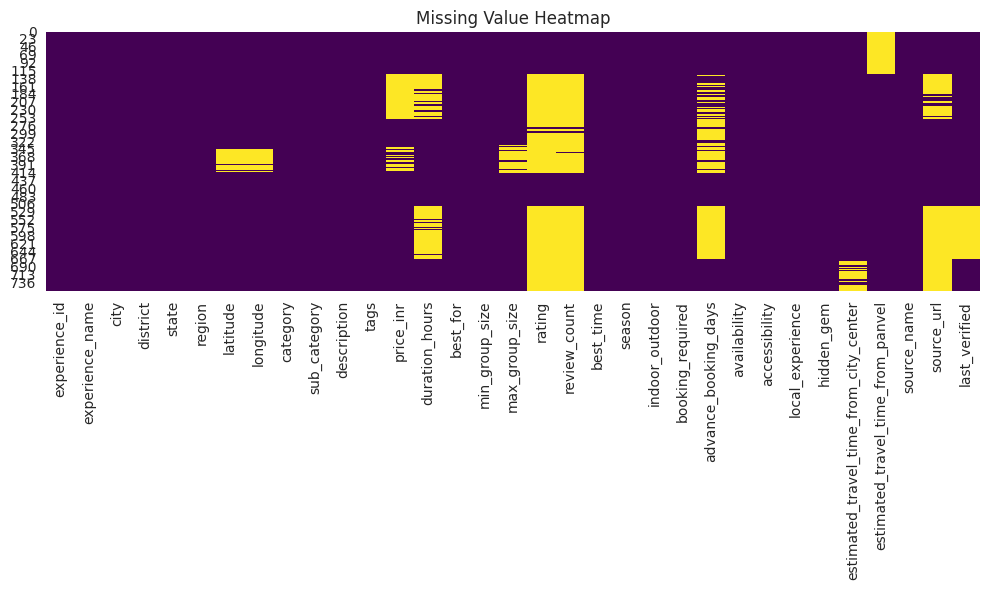

In [5]:
# ============================================================
# STEP 4: Missing values
# ============================================================
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_summary[missing_summary["missing_count"] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.tight_layout()
plt.show()

In [6]:
#============================================================
# STEP 5: Duplicate check
# ============================================================
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate experience_id:", df["experience_id"].duplicated().sum())
print("Duplicate experience_name:", df["experience_name"].duplicated().sum())

# ============================================================
# STEP 6: Descriptive statistics — numeric columns
# ============================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
df[numeric_cols].describe().T

Fully duplicated rows: 0
Duplicate experience_id: 0
Duplicate experience_name: 0
Numeric columns: ['latitude', 'longitude', 'price_inr', 'duration_hours', 'min_group_size', 'max_group_size', 'rating', 'review_count', 'advance_booking_days']


,count,mean,std,min,25%,50%,75%,max
latitude,691.0,20.256531,3.981661,15.8667,18.5485,19.03,19.2625,28.7554
longitude,691.0,73.813703,1.595150,72.7300,72.8722,73.07,73.4667,77.3630
price_inr,599.0,170.307179,425.708753,0.0000,0.0000,0.00,50.0000,3000.0000
duration_hours,515.0,2.482039,3.576538,0.2500,1.0000,1.50,2.5000,24.0000
min_group_size,757.0,1.212682,0.552481,1.0000,1.0000,1.00,1.0000,5.0000
max_group_size,684.0,15.517544,8.800937,2.0000,10.0000,15.00,20.0000,100.0000
rating,236.0,4.200847,0.248398,3.7000,4.0000,4.20,4.4000,4.7000
review_count,237.0,9191.333333,25548.276024,1.0000,410.0000,1900.00,6200.0000,210000.0000
advance_booking_days,450.0,0.331111,0.864628,0.0000,0.0000,0.00,0.0000,7.0000


In [7]:
# ============================================================
# STEP 7: Descriptive statistics — categorical columns
# ============================================================
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", cat_cols)
for col in ["category", "sub_category", "region", "state", "indoor_outdoor",
            "booking_required", "local_experience", "hidden_gem"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))

Categorical columns: ['experience_id', 'experience_name', 'city', 'district', 'state', 'region', 'category', 'sub_category', 'description', 'tags', 'best_for', 'best_time', 'season', 'indoor_outdoor', 'booking_required', 'availability', 'accessibility', 'local_experience', 'hidden_gem', 'estimated_travel_time_from_city_center', 'estimated_travel_time_from_panvel', 'source_name', 'source_url', 'last_verified']

--- category ---
category
Nature              133
Heritage             86
Beach                42
Culture              39
Food                 39
Adventure            37
Shopping             34
Temple               30
Photography          28
Family               26
Religious            22
Wildlife             21
Museum               18
Nightlife            16
Local Experience     15
Name: count, dtype: int64

--- sub_category ---
sub_category
Temple               19
Viewpoint            15
Coastal              13
Lake                 13
Beach                12
Waterfall          

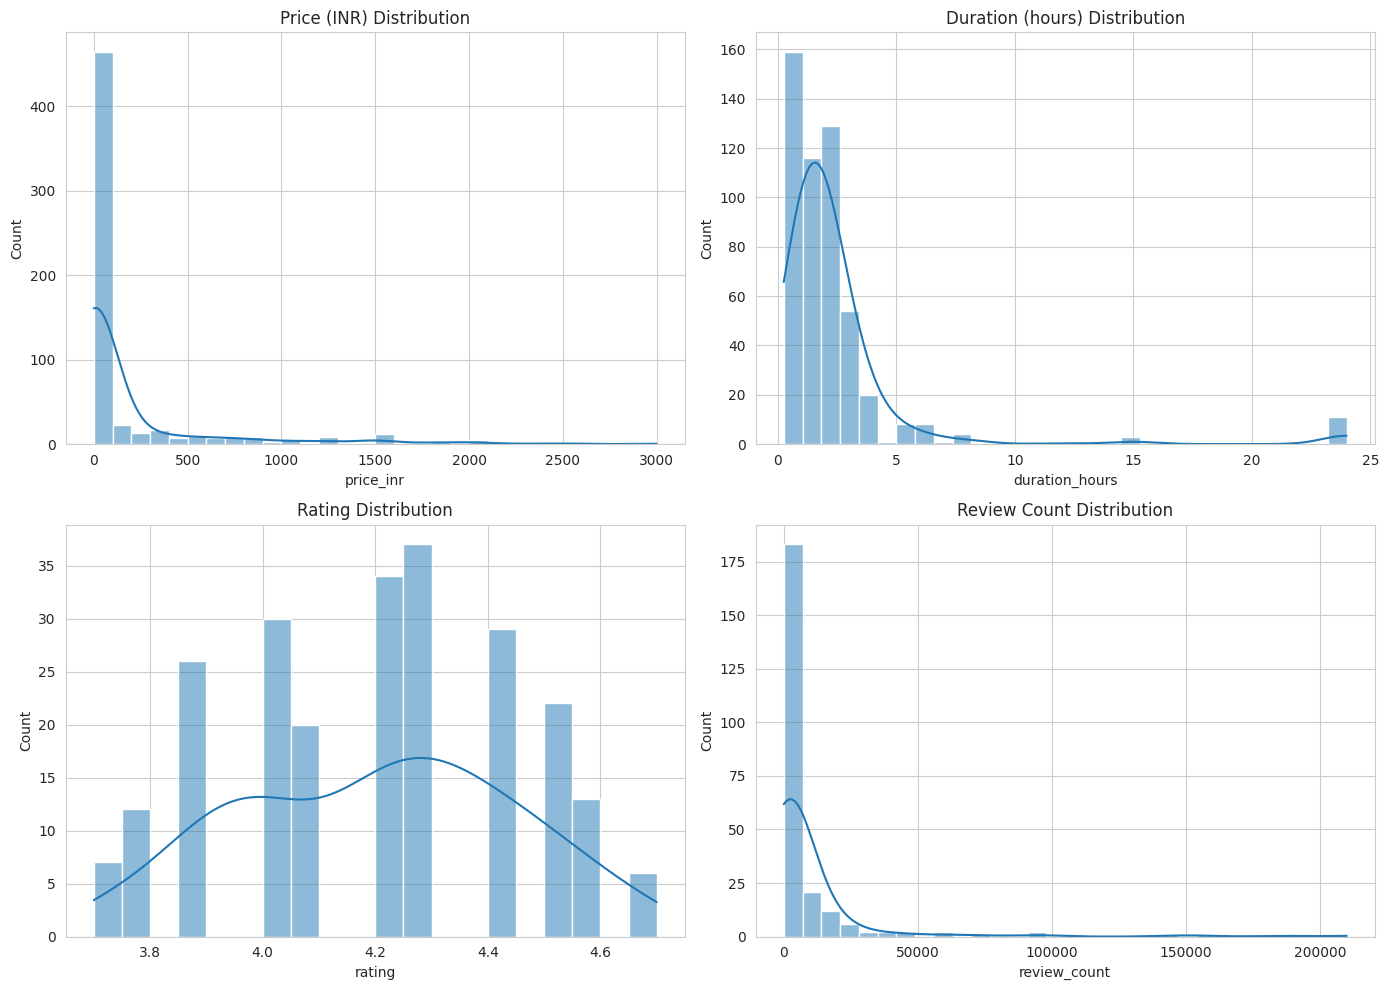

In [8]:
# ============================================================
# STEP 8: Univariate — distribution of key numeric fields
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df["price_inr"].dropna(), bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Price (INR) Distribution")

sns.histplot(df["duration_hours"].dropna(), bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Duration (hours) Distribution")

sns.histplot(df["rating"].dropna(), bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Rating Distribution")

sns.histplot(df["review_count"].dropna(), bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Review Count Distribution")
plt.tight_layout()
plt.show()

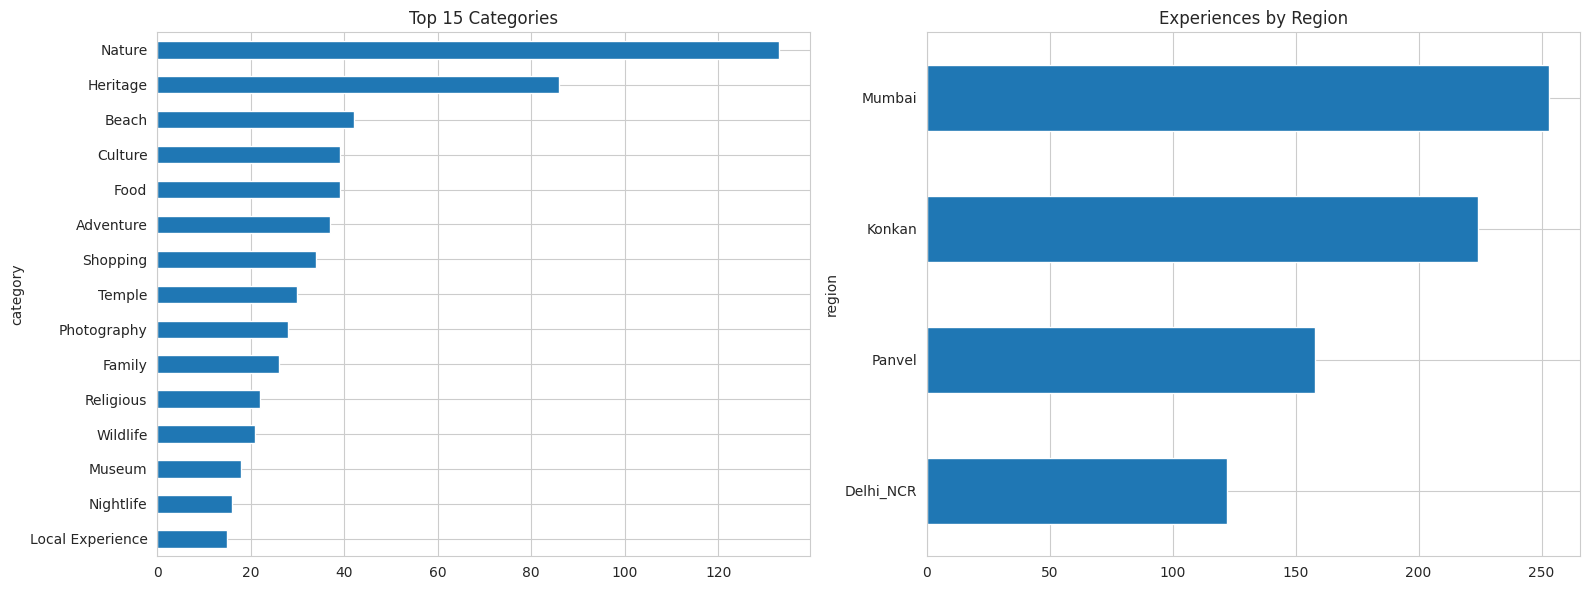

In [9]:
#============================================================
# STEP 9: Categorical distributions — top categories/regions
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df["category"].value_counts().head(15).plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 15 Categories")
axes[0].invert_yaxis()

df["region"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("Experiences by Region")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

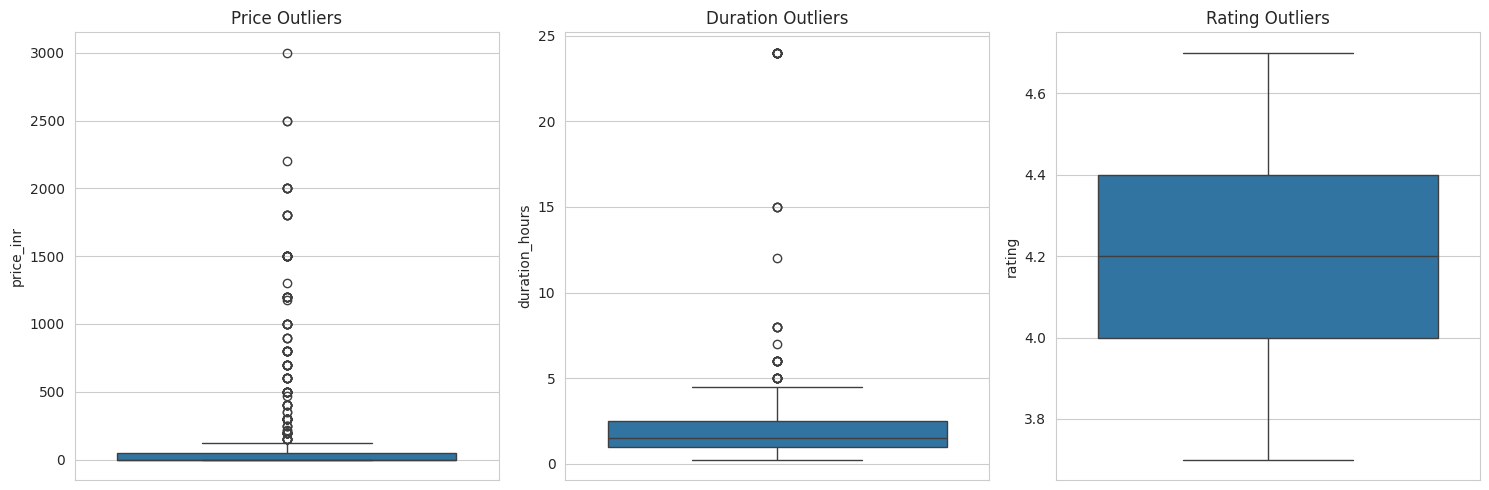

Price outliers (IQR method): 120 rows


In [10]:
# ============================================================
# STEP 10: Outlier detection (boxplots) — numeric fields
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df["price_inr"], ax=axes[0])
axes[0].set_title("Price Outliers")

sns.boxplot(y=df["duration_hours"], ax=axes[1])
axes[1].set_title("Duration Outliers")

sns.boxplot(y=df["rating"], ax=axes[2])
axes[2].set_title("Rating Outliers")
plt.tight_layout()
plt.show()

# IQR-based outlier count for price
Q1, Q3 = df["price_inr"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["price_inr"] < lower) | (df["price_inr"] > upper)]
print(f"Price outliers (IQR method): {len(outliers)} rows")

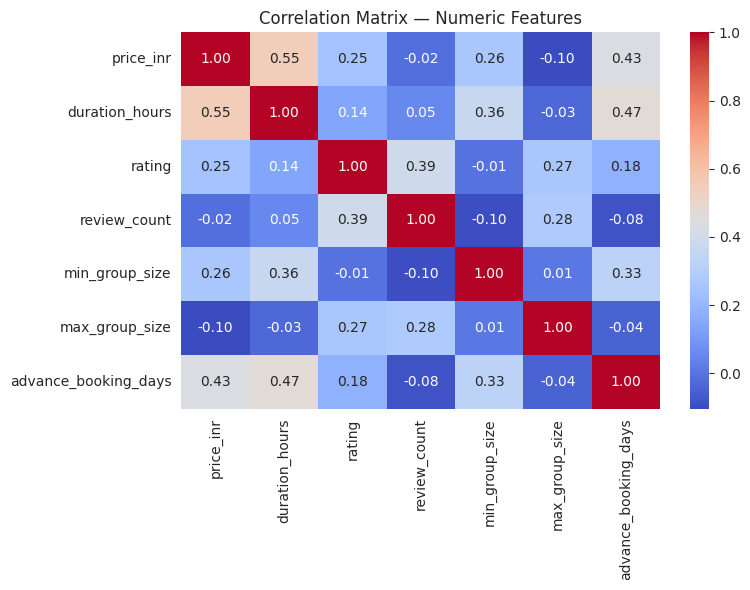

In [11]:
# ============================================================
# STEP 11: Bivariate — relationships between numeric variables
# ============================================================
corr_cols = ["price_inr", "duration_hours", "rating", "review_count",
             "min_group_size", "max_group_size", "advance_booking_days"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

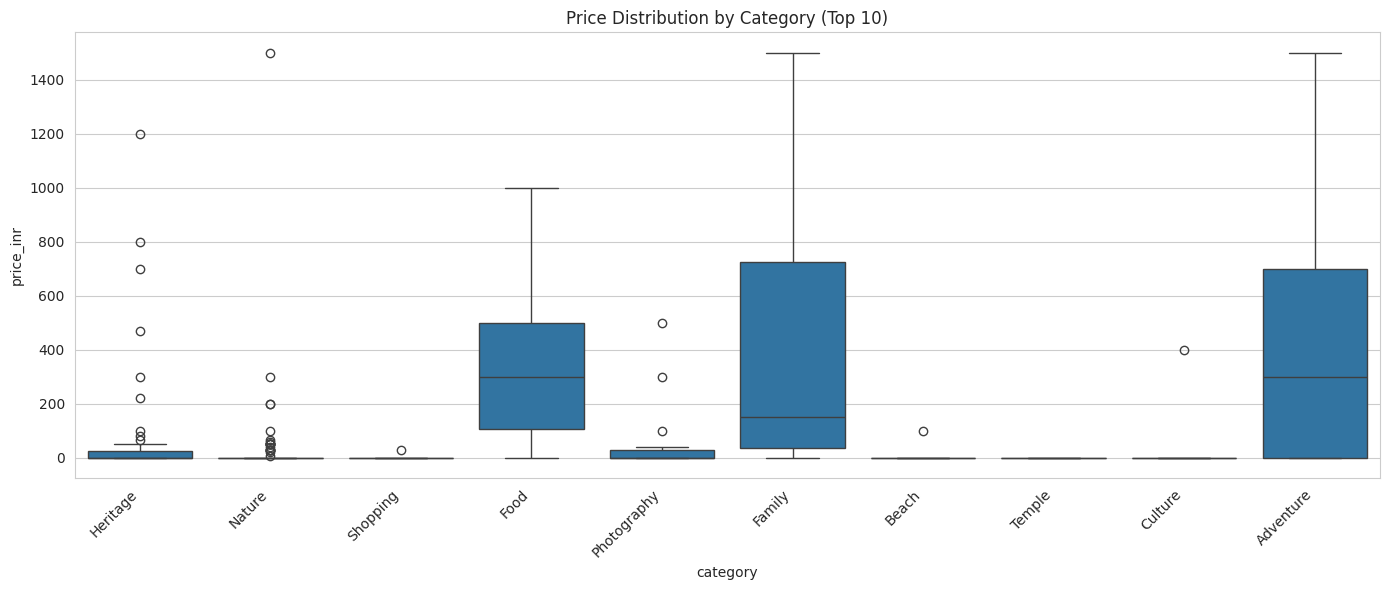

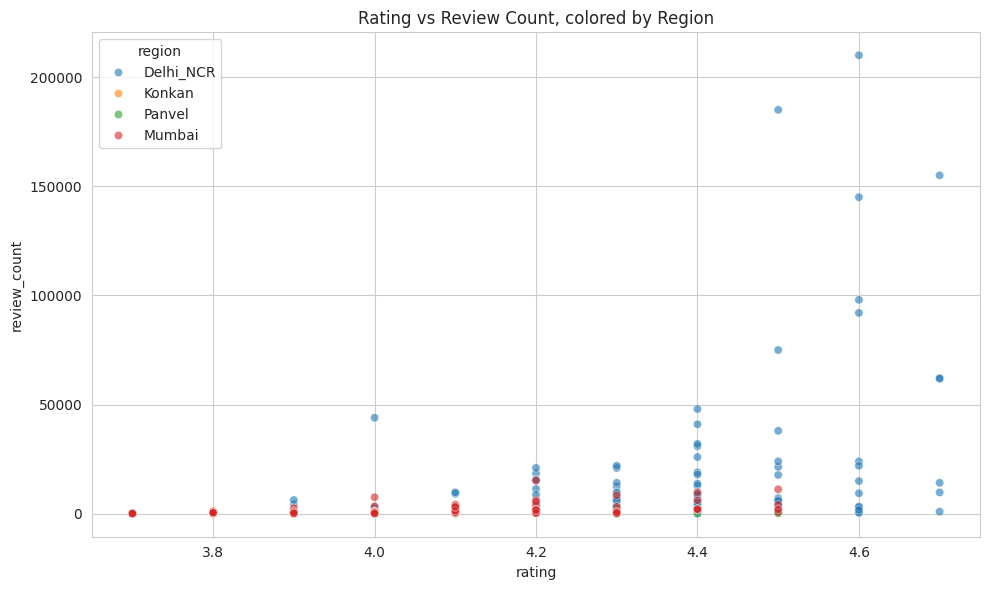

In [12]:
#============================================================
# STEP 12: Category vs numeric — e.g. price/rating by category
# ============================================================
plt.figure(figsize=(14, 6))
top_categories = df["category"].value_counts().head(10).index
sns.boxplot(data=df[df["category"].isin(top_categories)], x="category", y="price_inr")
plt.xticks(rotation=45, ha="right")
plt.title("Price Distribution by Category (Top 10)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="rating", y="review_count", hue="region", alpha=0.6)
plt.title("Rating vs Review Count, colored by Region")
plt.tight_layout()
plt.show()

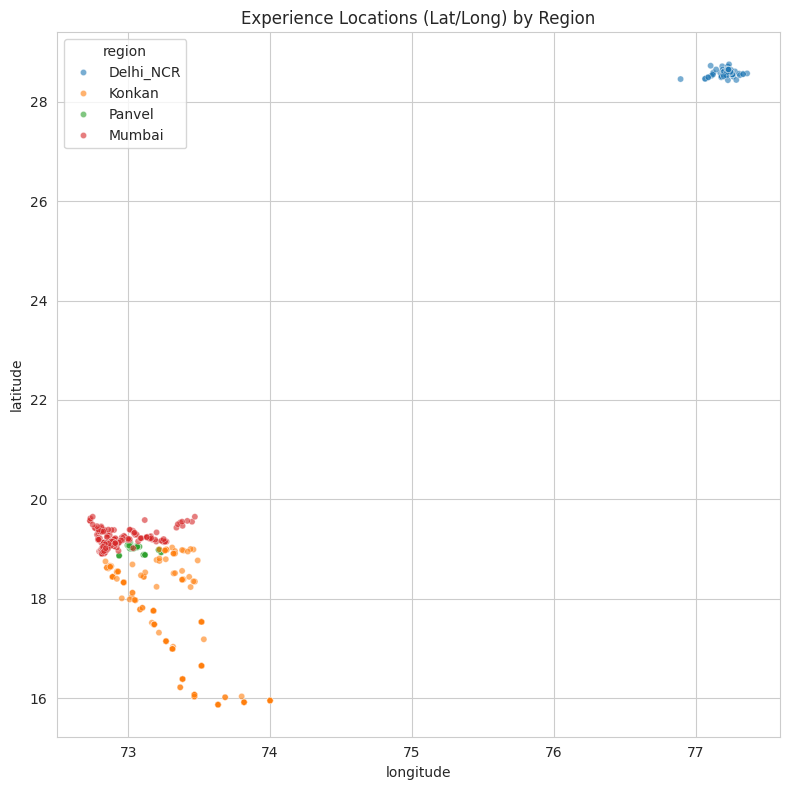

Top 20 tags:
tags
photography     75
heritage        49
beach           43
family          42
nature          41
temple          35
fort            30
hidden gem      30
history         29
trekking        22
offbeat         21
sunset          20
quiet           19
adventure       19
viewpoint       18
birdwatching    17
architecture    17
pilgrimage      17
culture         16
monsoon         15
Name: count, dtype: int64


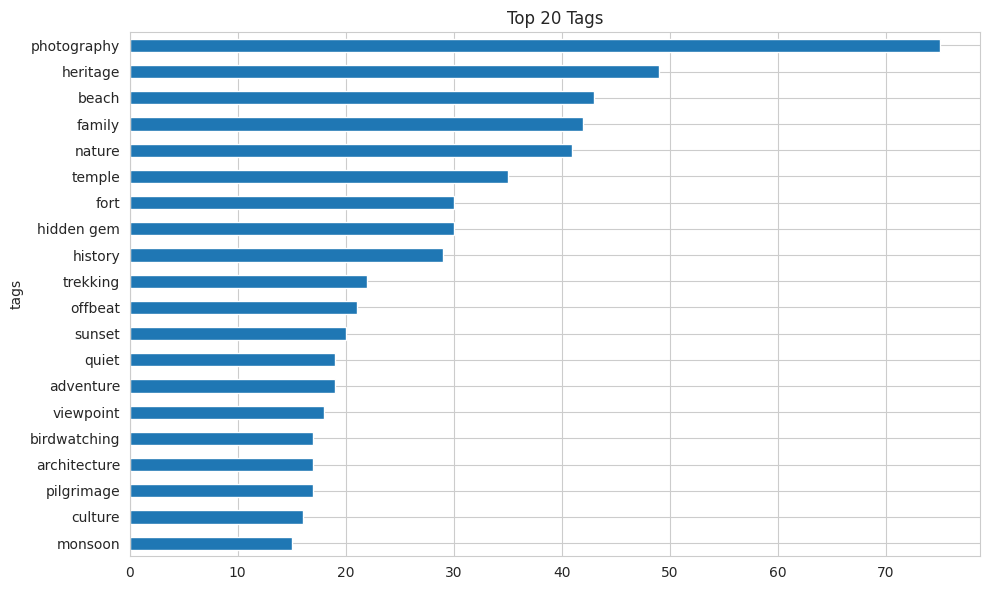

local_experience counts:
 local_experience
Yes      450
No       229
True      54
False     24
Name: count, dtype: int64

hidden_gem counts:
 hidden_gem
No       360
Yes      319
False     50
True      28
Name: count, dtype: int64

booking_required counts:
 booking_required
No             544
Yes             98
False           60
Recommended     31
True            18
Sometimes        4
Yes (boat)       1
Yes (ferry)      1
Name: count, dtype: int64

EDA complete.


In [13]:
# ============================================================
# STEP 13: Geospatial sanity check (lat/long scatter)
# ============================================================
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x="longitude", y="latitude", hue="region", alpha=0.6, s=20)
plt.title("Experience Locations (Lat/Long) by Region")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 14: Text field — tags exploration (multi-value column)
# ============================================================
all_tags = df["tags"].dropna().str.split(";").explode().str.strip()
print("Top 20 tags:")
print(all_tags.value_counts().head(20))

plt.figure(figsize=(10, 6))
all_tags.value_counts().head(20).plot(kind="barh")
plt.title("Top 20 Tags")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# STEP 15: Summary flags — quick sanity counts
# ============================================================
print("local_experience counts:\n", df["local_experience"].value_counts(dropna=False))
print("\nhidden_gem counts:\n", df["hidden_gem"].value_counts(dropna=False))
print("\nbooking_required counts:\n", df["booking_required"].value_counts(dropna=False))

# ============================================================
# STEP 16: Save a cleaned copy for downstream analysis (optional)
# ============================================================
# df.to_csv("all_experiences_cleaned.csv", index=False)
print("\nEDA complete.")

In [14]:
import pandas as pd
import numpy as np
import re


In [15]:
FILE_PATH = "/content/all_experiences_merged.csv"
OUT_PATH = "/content/all_experiences_cleaned.csv"

df = pd.read_csv(FILE_PATH, encoding="utf-8-sig")  # utf-8-sig strips BOM automatically

In [16]:
# ============================================================
# STEP 1: Clean column names (strip stray whitespace)
# ============================================================
df.columns = df.columns.str.strip()

# ============================================================
# STEP 2: Strip whitespace on every text/object column
# ============================================================
obj_cols = df.select_dtypes(include=["object", "string"]).columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

# ============================================================
# STEP 3: Clean price_inr -> numeric price_inr_clean
# Handles: "50", "0", "Free", "Free (donations optional)",
#          "Rs 25-50 entry", "Rs 300-800 for a meal", "Rs 10-20"
# Ranges become the midpoint; "Free" becomes 0.
# ============================================================
def clean_price(val):
    if pd.isna(val):
        return np.nan
    s = str(val).lower()
    if "free" in s:
        return 0.0
    nums = [float(n) for n in re.findall(r"\d+\.?\d*", s)]
    if not nums:
        return np.nan
    return sum(nums) / len(nums)  # midpoint if a range, else the single number

df["price_inr_clean"] = df["price_inr"].apply(clean_price)

# ============================================================
# STEP 4: Clean duration_hours -> numeric duration_hours_clean
# Handles: "2.5", "1-2", "0.25-0.5", "2-5 days typical", "4-24"
# "days" values are converted to hours (x24). Ranges -> midpoint.
# ============================================================
def clean_duration(val):
    if pd.isna(val):
        return np.nan
    s = str(val).lower()
    nums = [float(n) for n in re.findall(r"\d+\.?\d*", s)]
    if not nums:
        return np.nan
    midpoint = sum(nums) / len(nums)
    if "day" in s:
        midpoint *= 24
    return midpoint

df["duration_hours_clean"] = df["duration_hours"].apply(clean_duration)

# ============================================================
# STEP 5: Clean advance_booking_days -> numeric
# Handles: "0", "2-3 days", "0-1 day", "5-10 days (limited slots)", "3.0"
# ============================================================
def clean_days(val):
    if pd.isna(val):
        return np.nan
    nums = [float(n) for n in re.findall(r"\d+\.?\d*", str(val))]
    if not nums:
        return np.nan
    return sum(nums) / len(nums)

df["advance_booking_days_clean"] = df["advance_booking_days"].apply(clean_days)

# ============================================================
# STEP 6: Clean estimated_travel_time_from_city_center -> minutes
# Handles: "20 min", "10-15 min from Ratnagiri bus stand"
# ============================================================
def clean_travel_minutes(val):
    if pd.isna(val):
        return np.nan
    nums = [float(n) for n in re.findall(r"\d+\.?\d*", str(val))]
    if not nums:
        return np.nan
    return sum(nums) / len(nums)

df["travel_time_city_center_min"] = df["estimated_travel_time_from_city_center"].apply(clean_travel_minutes)

In [17]:
# ============================================================
# STEP 7: Clean estimated_travel_time_from_panvel -> hours + km
# Handles: "~6.5-7 hrs by road via NH66 (approx 330 km)", "30 min", NaN
# Produces two numeric columns: hours and km (NaN where not stated).
# ============================================================
def clean_panvel_hours(val):
    if pd.isna(val):
        return np.nan
    s = str(val).lower()
    if "min" in s and "hr" not in s:
        nums = [float(n) for n in re.findall(r"\d+\.?\d*", s)]
        return (sum(nums) / len(nums)) / 60 if nums else np.nan
    hr_match = re.findall(r"([\d.]+)\s*-?\s*([\d.]*)\s*hrs?", s)
    nums = [float(n) for n in re.findall(r"\d+\.?\d*", s.split("(")[0])]
    return sum(nums) / len(nums) if nums else np.nan

def clean_panvel_km(val):
    if pd.isna(val):
        return np.nan
    s = str(val).lower()
    km_match = re.search(r"approx\s*([\d.]+)\s*km", s)
    return float(km_match.group(1)) if km_match else np.nan

df["travel_time_panvel_hrs"] = df["estimated_travel_time_from_panvel"].apply(clean_panvel_hours)
df["travel_dist_panvel_km"] = df["estimated_travel_time_from_panvel"].apply(clean_panvel_km)

# ============================================================
# STEP 8: Standardize Yes/No/True/False -> boolean columns
# local_experience and hidden_gem are clean binary fields.
# booking_required has extra nuance (Recommended, Sometimes,
# "Yes (boat)") so we keep that detail in *_detail and also
# produce a clean True/False column.
# ============================================================
def to_bool(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in ("yes", "true"):
        return True
    if s in ("no", "false"):
        return False
    return np.nan  # ambiguous values handled separately below

df["local_experience_bool"] = df["local_experience"].apply(to_bool)
df["hidden_gem_bool"] = df["hidden_gem"].apply(to_bool)

df["booking_required_detail"] = df["booking_required"]  # keep original nuance
df["booking_required_bool"] = df["booking_required"].apply(
    lambda s: True if pd.notna(s) and str(s).strip().lower().startswith(("yes", "true", "recommended", "sometimes"))
    else (False if pd.notna(s) and str(s).strip().lower() in ("no", "false") else np.nan)
)

In [18]:
# ============================================================
# STEP 9: Standardize indoor_outdoor into 3 clean categories
# ============================================================
def clean_indoor_outdoor(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s == "indoor":
        return "Indoor"
    if s == "outdoor":
        return "Outdoor"
    return "Mixed"  # covers Both/Mixed/Indoor-Outdoor/Outdoor-Indoor variants

df["indoor_outdoor_clean"] = df["indoor_outdoor"].apply(clean_indoor_outdoor)

# ============================================================
# STEP 10: Duplicates
# ============================================================
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} fully duplicated rows")

dup_ids = df["experience_id"].duplicated().sum()
if dup_ids:
    print(f"Warning: {dup_ids} duplicate experience_id values remain — inspect manually")

# ============================================================
# STEP 11: Missing value handling
# - Numeric core fields: leave as NaN (don't fabricate), but flag them
# - max_group_size missing -> assumed same as min_group_size is risky,
#   so just flag rather than impute
# ============================================================
df["rating_missing"] = df["rating"].isna()
df["review_count_missing"] = df["review_count"].isna()
df["max_group_size_missing"] = df["max_group_size"].isna()

print("\nRemaining missing values per column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

# ============================================================
# STEP 12: Final sanity checks
# ============================================================
print("\nFinal shape:", df.shape)
print("\nCleaned numeric columns preview:")
print(df[[
    "price_inr", "price_inr_clean",
    "duration_hours", "duration_hours_clean",
    "advance_booking_days", "advance_booking_days_clean",
    "estimated_travel_time_from_city_center", "travel_time_city_center_min",
    "estimated_travel_time_from_panvel", "travel_time_panvel_hrs", "travel_dist_panvel_km",
    "indoor_outdoor", "indoor_outdoor_clean",
    "booking_required", "booking_required_bool",
    "local_experience", "local_experience_bool",
    "hidden_gem", "hidden_gem_bool",
]].head(10))

# ============================================================
# STEP 13: Save cleaned file
# ============================================================
df.to_csv(OUT_PATH, index=False)
print(f"\nSaved cleaned file to {OUT_PATH}")

Dropped 0 fully duplicated rows

Remaining missing values per column (top 15):
travel_dist_panvel_km                     626
rating                                    521
review_count                              520
source_url                                352
advance_booking_days                      266
advance_booking_days_clean                266
last_verified                             157
travel_time_panvel_hrs                    127
estimated_travel_time_from_panvel         122
travel_time_city_center_min               117
max_group_size                             73
longitude                                  66
latitude                                   66
estimated_travel_time_from_city_center     60
price_inr_clean                            29
dtype: int64

Final shape: (757, 47)

Cleaned numeric columns preview:
  price_inr  price_inr_clean duration_hours  duration_hours_clean advance_booking_days  advance_booking_days_clean  \
0        50             50.0            2.

In [19]:
#  Imports
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

pd.set_option('display.max_columns', 100)
print("Libraries loaded.")

Libraries loaded.


In [20]:
# Upload files (Colab file picker)
from google.colab import files

print("Upload synthetic_traveler_interactions.csv and all_experiences_cleaned.csv")
uploaded = files.upload()

Upload synthetic_traveler_interactions.csv and all_experiences_cleaned.csv


Saving synthetic_traveler_interactions.csv to synthetic_traveler_interactions.csv
Saving all_experiences_cleaned.csv to all_experiences_cleaned (1).csv


In [21]:
# Load CSVs
df_interactions = pd.read_csv('synthetic_traveler_interactions.csv')
df_experiences = pd.read_csv('all_experiences_cleaned.csv')

print("Interactions:", df_interactions.shape)
print("Experiences:", df_experiences.shape)

Interactions: (15140, 17)
Experiences: (757, 47)


In [22]:
# Inspection
for name, df in [('INTERACTIONS', df_interactions), ('EXPERIENCES', df_experiences)]:
    print(f"\n{'='*20} {name} {'='*20}")
    print("Shape:", df.shape)
    print("\nColumns & dtypes:\n", df.dtypes)
    print("\nMissing values (only >0):\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nSample records:\n", df.head(3))

print("\nTarget distribution (match_label):")
print(df_interactions['match_label'].value_counts(normalize=True))


==================== INTERACTIONS ====================
Shape: (15140, 17)

Columns & dtypes:
 traveler_id                   object
budget_inr                     int64
available_time_hours           int64
traveler_count                 int64
group_type                    object
interests                     object
experience_id                 object
interest_match                 int64
budget_match                   int64
time_match                     int64
group_match                    int64
distance_match                 int64
experience_price_inr           int64
experience_duration_hours    float64
experience_rating            float64
match_score_bootstrap        float64
match_label                    int64
dtype: object

Missing values (only >0):
 Series([], dtype: int64)

Duplicate rows: 0

Sample records:
   traveler_id  budget_inr  available_time_hours  traveler_count group_type                     interests experience_id  interest_match  \
0      T00001         300         

In [23]:
# Validate experience_id relationship
ids_in_interactions = set(df_interactions['experience_id'].unique())
ids_in_db = set(df_experiences['experience_id'].unique())

print("Unique experience_id in interactions:", len(ids_in_interactions))
print("Unique experience_id in experience DB:", len(ids_in_db))
print("In interactions but missing from DB:", len(ids_in_interactions - ids_in_db))
print("In DB but never used in interactions:", len(ids_in_db - ids_in_interactions))

assert df_experiences['experience_id'].duplicated().sum() == 0, "Duplicate experience_id in DB!"
print("\nexperience_id is a clean, matching join key between both files.")

Unique experience_id in interactions: 757
Unique experience_id in experience DB: 757
In interactions but missing from DB: 0
In DB but never used in interactions: 0

experience_id is a clean, matching join key between both files.


In [24]:
# Feature engineering
# We do NOT use traveler_id, experience_id, or match_label as features.
# We also exclude match_score_bootstrap, interest_match, budget_match, time_match,
# group_match, distance_match — these were found to be near-deterministic generators
# of match_label itself (data leakage), so training on them would let the model
# just memorize the labeling rule instead of learning real patterns.
# We also ignore the interaction file's own experience_price_inr/duration/rating
# columns, since ~80-220 experiences had mismatched values vs. the experience DB;
# we join the authoritative values from all_experiences_cleaned.csv instead.

exp_cols = ['experience_id', 'experience_name', 'city', 'category', 'sub_category',
            'tags', 'best_for', 'price_inr_clean', 'duration_hours_clean', 'rating',
            'rating_missing', 'min_group_size', 'max_group_size',
            'indoor_outdoor_clean', 'local_experience_bool', 'hidden_gem_bool']
df_exp_sub = df_experiences[exp_cols].copy()

df = df_interactions.merge(df_exp_sub, on='experience_id', how='left')
assert df['experience_name'].isna().sum() == 0, "Some experience_ids failed to join!"

def _tokenize(s, sep):
    if pd.isna(s):
        return set()
    return set(t.strip().lower() for t in str(s).split(sep) if t.strip())

def compute_interest_overlap(interests, tags, category, best_for):
    traveler_tokens = _tokenize(interests, '|')
    exp_tokens = _tokenize(tags, ';') | _tokenize(category, ';') | _tokenize(best_for, ';')
    overlap = traveler_tokens & exp_tokens
    overlap_count = len(overlap)
    overlap_ratio = overlap_count / len(traveler_tokens) if traveler_tokens else 0.0
    return overlap_count, overlap_ratio

overlap_results = df.apply(
    lambda r: compute_interest_overlap(r['interests'], r['tags'], r['category'], r['best_for']),
    axis=1
)
df['interest_overlap_count'] = overlap_results.apply(lambda t: t[0])
df['interest_overlap_ratio'] = overlap_results.apply(lambda t: t[1])

df['price_diff'] = df['budget_inr'] - df['price_inr_clean']
df['affordable'] = (df['price_inr_clean'] <= df['budget_inr']).astype(int)
df['time_diff'] = df['available_time_hours'] - df['duration_hours_clean']
df['fits_time'] = (df['duration_hours_clean'] <= df['available_time_hours']).astype(int)

max_group_filled = df['max_group_size'].fillna(999)
df['group_size_ok'] = (
    (df['traveler_count'] >= df['min_group_size']) &
    (df['traveler_count'] <= max_group_filled)
).astype(int)

df['local_experience_bool'] = df['local_experience_bool'].astype(int)
df['hidden_gem_bool'] = df['hidden_gem_bool'].astype(int)
df['rating_missing'] = df['rating_missing'].astype(int)

numeric_features = ['budget_inr', 'available_time_hours', 'traveler_count',
                     'price_inr_clean', 'duration_hours_clean', 'rating',
                     'price_diff', 'time_diff', 'interest_overlap_count', 'interest_overlap_ratio']
binary_features = ['affordable', 'fits_time', 'group_size_ok',
                    'local_experience_bool', 'hidden_gem_bool', 'rating_missing']
categorical_features = ['group_type', 'category', 'sub_category', 'indoor_outdoor_clean']

feature_cols = numeric_features + binary_features + categorical_features
X = df[feature_cols].copy()
y = df['match_label'].copy()
groups = df['traveler_id'].copy()   # needed for the group-aware split in CELL 7

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Feature matrix shape:", X.shape)
print("Missing values per feature (>0 only):\n", X.isna().sum()[X.isna().sum() > 0])

Feature matrix shape: (15140, 20)
Missing values per feature (>0 only):
 price_inr_clean      580
rating             10420
price_diff           580
dtype: int64


In [25]:
# Group-aware train/test split
# The dataset is a full cross-join of only 20 travelers x 757 experiences, so every
# traveler appears in ~757 rows. A random row-level split would put the SAME
# traveler's rows in both train and test, letting the model "recognize" that
# traveler rather than generalize -> optimistic, leaky evaluation.
# GroupShuffleSplit instead splits by traveler_id, so entire travelers (and all
# their rows) go either fully into train or fully into test.

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train travelers: {groups.iloc[train_idx].nunique()} | Test travelers: {groups.iloc[test_idx].nunique()}")
print(f"Train records: {len(X_train)} | Test records: {len(X_test)}")

Train travelers: 15 | Test travelers: 5
Train records: 11355 | Test records: 3785


In [26]:
# Train model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        class_weight='balanced'   # match_label is ~76% / 24% imbalanced
    ))
])

model_pipeline.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [27]:
# Evaluation
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("Confusion matrix:\n", cm)

Accuracy:  0.9022
Precision: 0.8945
Recall:    0.6903
F1-score:  0.7792
ROC-AUC:   0.8414
Confusion matrix:
 [[2762   77]
 [ 293  653]]


In [28]:
# Feature importance
fitted_preprocessor = model_pipeline.named_steps['preprocessor']
fitted_model = model_pipeline.named_steps['classifier']

cat_feature_names = fitted_preprocessor.named_transformers_['cat'].named_steps['onehot'] \
    .get_feature_names_out(categorical_features)
all_feature_names = numeric_features + binary_features + list(cat_feature_names)

importances = pd.Series(fitted_model.feature_importances_, index=all_feature_names) \
    .sort_values(ascending=False)

print("Top 15 features:")
print(importances.head(15))

Top 15 features:
interest_overlap_ratio    0.356274
interest_overlap_count    0.300627
price_diff                0.027055
available_time_hours      0.026628
traveler_count            0.024253
time_diff                 0.023560
budget_inr                0.023477
group_type_Family         0.016936
group_type_Solo           0.012116
group_type_Friends        0.011655
category_Nature           0.010599
duration_hours_clean      0.009496
group_type_Couple         0.009355
category_Beach            0.008481
category_Heritage         0.007527
dtype: float64


In [29]:
# Save artifacts
joblib.dump(fitted_preprocessor, 'preprocessing_pipeline.pkl')
joblib.dump(fitted_model, 'recommendation_model.pkl')
print("Saved: preprocessing_pipeline.pkl, recommendation_model.pkl")

Saved: preprocessing_pipeline.pkl, recommendation_model.pkl


In [30]:
# Load back and verify
loaded_preprocessor = joblib.load('preprocessing_pipeline.pkl')
loaded_model = joblib.load('recommendation_model.pkl')

X_test_transformed = loaded_preprocessor.transform(X_test)
proba_check = loaded_model.predict_proba(X_test_transformed)[:, 1]

print("Loaded artifacts match original predictions:", np.allclose(proba_check, y_proba))

Loaded artifacts match original predictions: True


In [31]:
# Recommendation function with location filter
def recommend_experiences(budget_inr, available_time_hours, traveler_count,
                           group_type, interests, location=None, top_n=10):
    candidates = df_experiences[df_experiences['duration_hours_clean'].notna()].copy()

    # Optional location filter — matches against city, district, or region
    # (case-insensitive substring match, so "konkan" or "alibag" both work)
    if location:
        loc = location.strip().lower()
        loc_mask = (
            candidates['city'].str.lower().str.contains(loc, na=False) |
            candidates['district'].str.lower().str.contains(loc, na=False) |
            candidates['region'].str.lower().str.contains(loc, na=False)
        )
        candidates = candidates[loc_mask]
        if candidates.empty:
            print(f"No experiences found for location '{location}'. Showing all locations instead.")
            candidates = df_experiences[df_experiences['duration_hours_clean'].notna()].copy()

    rows = []
    for _, exp in candidates.iterrows():
        oc, orat = compute_interest_overlap(interests, exp['tags'], exp['category'], exp['best_for'])
        price = exp['price_inr_clean']
        duration = exp['duration_hours_clean']
        min_g = exp['min_group_size']
        max_g = exp['max_group_size'] if not pd.isna(exp['max_group_size']) else 999

        rows.append({
            'experience_id': exp['experience_id'],
            'budget_inr': budget_inr,
            'available_time_hours': available_time_hours,
            'traveler_count': traveler_count,
            'price_inr_clean': price,
            'duration_hours_clean': duration,
            'rating': exp['rating'],
            'price_diff': budget_inr - price if pd.notna(price) else np.nan,
            'time_diff': available_time_hours - duration if pd.notna(duration) else np.nan,
            'interest_overlap_count': oc,
            'interest_overlap_ratio': orat,
            'affordable': int(price <= budget_inr) if pd.notna(price) else 0,
            'fits_time': int(duration <= available_time_hours) if pd.notna(duration) else 0,
            'group_size_ok': int(min_g <= traveler_count <= max_g),
            'local_experience_bool': int(exp['local_experience_bool']),
            'hidden_gem_bool': int(exp['hidden_gem_bool']),
            'rating_missing': int(exp['rating_missing']),
            'group_type': group_type,
            'category': exp['category'],
            'sub_category': exp['sub_category'],
            'indoor_outdoor_clean': exp['indoor_outdoor_clean'],
        })

    feat_df = pd.DataFrame(rows)

    mask = (feat_df['affordable'] == 1) & (feat_df['fits_time'] == 1)
    filtered = feat_df[mask].copy()
    if filtered.empty:
        filtered = feat_df.copy()

    Xc = filtered[feature_cols]
    Xt = loaded_preprocessor.transform(Xc)
    filtered['recommendation_score'] = loaded_model.predict_proba(Xt)[:, 1]

    result = filtered.merge(
        df_experiences[['experience_id', 'experience_name', 'city']],
        on='experience_id', how='left'
    )
    result = result.sort_values('recommendation_score', ascending=False).head(top_n)

    return result[['experience_id', 'experience_name', 'category', 'city',
                    'price_inr_clean', 'duration_hours_clean', 'rating', 'recommendation_score']]

print("recommend_experiences() ready (now supports location filtering).")

recommend_experiences() ready (now supports location filtering).


In [32]:
recs = recommend_experiences(
    budget_inr=4000,
    available_time_hours=2,
    traveler_count=5,
    group_type='Friends',
    interests='adventure|nature',   # swap in your actual interests
    location='Panvel',
    top_n=20
)
recs.reset_index(drop=True)

,experience_id,experience_name,category,city,price_inr_clean,duration_hours_clean,rating,recommendation_score
0,PANVEL-050,"Bhivpuri Waterfall Picnic, Karjat",Nature,Karjat,0.0,2.0,NaN,0.842781
1,NAVI-039,Seawoods Lake,Nature,Seawoods,0.0,1.0,NaN,0.840883
2,PANVEL-034,Bot Lake Karnala Nature Walk,Nature,Karnala (Panvel),0.0,1.0,NaN,0.838762
3,PANVEL-051,"Pali Bhutivali Dam Backwaters Picnic, Karjat",Nature,Karjat,0.0,2.0,NaN,0.837955
4,NAVI-004,Kharghar Hills Sunrise Point,Nature,Kharghar,0.0,2.0,4.2,0.837887
5,NAVI-005,Owe Dam,Nature,Kharghar,0.0,1.5,NaN,0.837797
6,NAVI-045,Gavlidevi Waterfall and Birding Mahape,Nature,Ghansoli,0.0,2.0,NaN,0.836348
7,PANVEL-040,Ransai Dam Uran,Nature,Uran,0.0,1.5,NaN,0.836138
8,PANVEL-024,Owe Dam Kharghar Viewpoint,Nature,Kharghar,0.0,1.0,NaN,0.835279
9,PANVEL-063,"Hast Mudra Themed Garden, Central Park Kharghar",Nature,Kharghar,0.0,1.0,NaN,0.835279


In [33]:
# Additional test profiles
profiles = [
    dict(budget_inr=500,  available_time_hours=2, traveler_count=1, group_type='Solo',
         interests='heritage|photography'),
    dict(budget_inr=3000, available_time_hours=8, traveler_count=6, group_type='Family',
         interests='wildlife|nature|food'),
    dict(budget_inr=800,  available_time_hours=3, traveler_count=2, group_type='Couple',
         interests='beach|sunset|nightlife'),
    dict(budget_inr=2000, available_time_hours=6, traveler_count=4, group_type='Friends',
         interests='adventure|sports|trekking'),
]

for i, p in enumerate(profiles, start=1):
    print(f"\n{'='*10} Profile {i}: {p} {'='*10}")
    recs = recommend_experiences(**p, top_n=5).reset_index(drop=True)
    recs.index = recs.index + 1
    print(recs[['experience_name', 'category', 'city', 'price_inr_clean',
                'duration_hours_clean', 'rating', 'recommendation_score']])

# ---- Final summary ----
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Number of experiences:      {df_experiences.shape[0]}")
print(f"Number of interaction rows: {df_interactions.shape[0]}")
print(f"Number of input features:   {len(feature_cols)} (before one-hot expansion)")
print(f"Training records:           {len(X_train)}")
print(f"Test records:               {len(X_test)}")
print(f"Model accuracy:             {acc:.4f}")
print(f"F1-score:                   {f1:.4f}")
print(f"ROC-AUC:                    {roc_auc:.4f}")
print("Saved model files:          recommendation_model.pkl, preprocessing_pipeline.pkl (Colab working directory)")
print()
print("NOTE: match_label is a synthetic, rule-based bootstrap label used for this")
print("hackathon prototype. These metrics measure how well the model reproduces")
print("that synthetic rule, NOT real-world traveler satisfaction or preference accuracy.")


========== Profile 1: {'budget_inr': 500, 'available_time_hours': 2, 'traveler_count': 1, 'group_type': 'Solo', 'interests': 'heritage|photography'} ==========
                         experience_name   category         city  price_inr_clean  duration_hours_clean  rating  recommendation_score
1               Rajapuri Jetty Boat Ride  Adventure        Murud             60.0                   1.0     NaN              0.815545
2  Reliance Corporate Park Ghansoli Walk    Culture     Ghansoli              0.0                   1.0     NaN              0.814089
3                           Belapur Fort    Culture  CBD Belapur              0.0                   1.5     NaN              0.812435
4                  Suvarna Ganesh Temple    Culture     Diveagar              0.0                   1.0     NaN              0.808673
5         Alibag Local Fish Market Visit    Culture       Alibag              0.0                   1.0     NaN              0.808529

========== Profile 2: {'budget_inr

In [34]:
# CELL 16: Haversine distance + location-by-coordinates filter
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def get_scored_candidates(budget_inr, available_time_hours, traveler_count,
                           group_type, interests,
                           user_lat=None, user_lon=None, radius_km=25):
    """Filters by distance (if lat/lon given), scores every candidate with the model,
    but does NOT enforce time/budget as a group yet — that's the optimizer's job."""
    candidates = df_experiences[df_experiences['duration_hours_clean'].notna()].copy()

    if user_lat is not None and user_lon is not None:
        candidates = candidates[candidates['latitude'].notna() & candidates['longitude'].notna()].copy()
        candidates['distance_km'] = haversine_km(user_lat, user_lon,
                                                  candidates['latitude'], candidates['longitude'])
        candidates = candidates[candidates['distance_km'] <= radius_km]
        if candidates.empty:
            print(f"No experiences within {radius_km} km. Try a larger radius.")
            return pd.DataFrame()
    else:
        candidates['distance_km'] = np.nan

    rows = []
    for _, exp in candidates.iterrows():
        oc, orat = compute_interest_overlap(interests, exp['tags'], exp['category'], exp['best_for'])
        price = exp['price_inr_clean']
        duration = exp['duration_hours_clean']
        min_g = exp['min_group_size']
        max_g = exp['max_group_size'] if not pd.isna(exp['max_group_size']) else 999

        rows.append({
            'experience_id': exp['experience_id'],
            'experience_name': exp['experience_name'],
            'city': exp['city'],
            'latitude': exp['latitude'], 'longitude': exp['longitude'],
            'distance_km': exp['distance_km'],
            'budget_inr': budget_inr, 'available_time_hours': available_time_hours,
            'traveler_count': traveler_count,
            'price_inr_clean': price, 'duration_hours_clean': duration, 'rating': exp['rating'],
            'price_diff': budget_inr - price if pd.notna(price) else np.nan,
            'time_diff': available_time_hours - duration if pd.notna(duration) else np.nan,
            'interest_overlap_count': oc, 'interest_overlap_ratio': orat,
            'affordable': int(price <= budget_inr) if pd.notna(price) else 0,
            'fits_time': int(duration <= available_time_hours) if pd.notna(duration) else 0,
            'group_size_ok': int(min_g <= traveler_count <= max_g),
            'local_experience_bool': int(exp['local_experience_bool']),
            'hidden_gem_bool': int(exp['hidden_gem_bool']),
            'rating_missing': int(exp['rating_missing']),
            'group_type': group_type, 'category': exp['category'],
            'sub_category': exp['sub_category'], 'indoor_outdoor_clean': exp['indoor_outdoor_clean'],
        })

    feat_df = pd.DataFrame(rows)
    Xt = loaded_preprocessor.transform(feat_df[feature_cols])
    feat_df['recommendation_score'] = loaded_model.predict_proba(Xt)[:, 1]
    return feat_df

print("get_scored_candidates() ready.")

get_scored_candidates() ready.


In [35]:
# CELL 17: Knapsack-style itinerary builder
# Picks a COMBINATION of experiences whose total duration <= available_time_hours
# AND total price <= budget_inr, maximizing total recommendation_score.
# Uses two greedy heuristics and keeps the better one (fast, no extra dependencies
# — good enough for a hackathon; swap for PuLP/OR-Tools later if you want optimal).

def build_itinerary(scored_df, available_time_hours, budget_inr, max_stops=5):
    if scored_df.empty:
        return pd.DataFrame()

    df_ = scored_df.copy()
    df_ = df_[(df_['duration_hours_clean'] <= available_time_hours) &
              (df_['price_inr_clean'] <= budget_inr)]
    if df_.empty:
        return pd.DataFrame()

    def greedy(sort_col, ascending=False):
        remaining_time = available_time_hours
        remaining_budget = budget_inr
        picked = []
        for _, row in df_.sort_values(sort_col, ascending=ascending).iterrows():
            if len(picked) >= max_stops:
                break
            if row['duration_hours_clean'] <= remaining_time and row['price_inr_clean'] <= remaining_budget:
                if any(p['experience_id'] == row['experience_id'] for p in picked):
                    continue
                picked.append(row)
                remaining_time -= row['duration_hours_clean']
                remaining_budget -= row['price_inr_clean']
        return picked

    # Heuristic A: highest score first
    option_a = greedy('recommendation_score', ascending=False)
    # Heuristic B: best score-per-hour (favors fitting more short, high-value stops)
    df_['score_per_hour'] = df_['recommendation_score'] / df_['duration_hours_clean'].replace(0, 0.25)
    option_b = greedy('score_per_hour', ascending=False)

    best = option_a if sum(r['recommendation_score'] for r in option_a) >= \
                        sum(r['recommendation_score'] for r in option_b) else option_b

    if not best:
        return pd.DataFrame()

    itinerary = pd.DataFrame(best)

    # Order stops by nearest-neighbor from current location (if distance available)
    if itinerary['distance_km'].notna().all():
        itinerary = itinerary.sort_values('distance_km').reset_index(drop=True)

    itinerary['total_time_used'] = itinerary['duration_hours_clean'].cumsum()
    itinerary['total_budget_used'] = itinerary['price_inr_clean'].cumsum()
    return itinerary[['experience_id', 'experience_name', 'city', 'category',
                       'price_inr_clean', 'duration_hours_clean', 'rating',
                       'distance_km', 'recommendation_score',
                       'total_time_used', 'total_budget_used']]

print("build_itinerary() ready.")

build_itinerary() ready.


In [36]:
# CELL 18: Test — 2 hrs, ₹4000, 5 people (you + 4 friends), somewhere nearby
scored = get_scored_candidates(
    budget_inr=4000, available_time_hours=5, traveler_count=3,
    group_type='Friends', interests='food',
    user_lat=18.9904, user_lon=73.1281,   # example: swap in real coords
    radius_km=20
)

itinerary = build_itinerary(scored, available_time_hours=5, budget_inr=4000, max_stops=10)
print(itinerary.to_string(index=False))

experience_id                   experience_name     city category  price_inr_clean  duration_hours_clean  rating  distance_km  recommendation_score  total_time_used  total_budget_used
     NAVI-054             Biryani Guru Kharghar Kharghar     Food            350.0                   1.0     NaN     8.626142              0.805657              1.0              350.0
     NAVI-007       Utsav Chowk Street Food Hub Kharghar     Food            150.0                   1.5     NaN     8.871615              0.827457              2.5              500.0
     NAVI-072           Utsav Chowk Momo Stalls Kharghar     Food            100.0                   1.0     NaN     8.871615              0.823370              3.5              600.0
     NAVI-018 Sector 17 Street Food Strip Vashi    Vashi     Food            120.0                   1.0     NaN    16.693711              0.823370              4.5              720.0
     NAVI-056     Vashi Station Vada Pav Stalls    Vashi     Food             30